In [7]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnableConfig
from langchain_openai import ChatOpenAI
from langgraph.graph import END, START, StateGraph
from typing_extensions import TypedDict, Literal
import json, random


# Load Fold 5 Datasets

In [64]:
# Setting file paths
fold_path = os.path.join(os.path.dirname(os.getcwd()), 'data', 'pqal_fold2')
train_data = json.load(open(os.path.join(fold_path, "train_set.json")))
dev_data = json.load(open(os.path.join(fold_path, "dev_set.json")))

print(f"# Train examples: {len(train_data)}")
print(f"# Dev examples: {len(dev_data)}")


# Train examples: 450
# Dev examples: 50


# Select Few-Shot Examples from Train Set

In [6]:
import random

few_shot_examples = random.sample(list(train_data.values()), 5)


# Define Prompt Template

In [8]:
def build_prompt(example, few_shot):
    prompt_text = "You are a biomedical agent. Based on the abstract and question, answer with 'yes', 'no', or 'maybe'.\n\n"
    for i, ex in enumerate(few_shot):
        prompt_text += f"Example {i+1}:\nQUESTION: {ex['QUESTION']}\nABSTRACT: {' '.join(ex['CONTEXTS'])}\nANSWER: {ex['final_decision']}\n\n"
    prompt_text += f"Now answer this:\nQUESTION: {example['question']}\nABSTRACT: {example['context']}\nANSWER:"
    return prompt_text


# Define output schema

In [11]:
# class AnswerOutput(TypedDict):
#     answer: Literal["yes", "no", "maybe"]

class AgentState(TypedDict):
    question: str
    context: str
    answer: Literal["yes", "no", "maybe"]


llm = ChatOpenAI(model="gpt-4o-mini")

# prompt_node = lambda x: {"content": build_prompt(x, few_shot_examples)}
# llm_node = llm.with_structured_output(AnswerOutput)


# Define Graph Flow

In [74]:
from langgraph.graph import StateGraph

builder = StateGraph(state_schema=AgentState)


# Define the function normally
def ask_llm(state: AgentState) -> AgentState:
    # Use the prompt builder
    few_shot_examples = random.sample(list(train_data.values()), 10)

    prompt_text = build_prompt(state, few_shot_examples)

    # Call the LLM
    response = llm.invoke([HumanMessage(content=prompt_text)])

    return {
        **state,
        "answer": response.content.strip().lower()
    }

# Then register it with the graph
builder.add_node("ask_llm", ask_llm)
builder.set_entry_point("ask_llm")
graph = builder.compile()


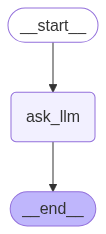

In [75]:
from IPython.display import Image

# Show graph as PNG (may be incomplete — doesn’t show conditional edges)
Image(graph.get_graph().draw_mermaid_png())

# Run Inference

In [76]:
from langchain_core.messages import HumanMessage

# Test example
sample_question = {
    "question": "Does the enteral feeding advancement affect short-term outcomes in very low birth weight infants?",
    "context": """
    Controversy exists regarding the optimal enteral feeding regimen of very low birth weight infants (VLBW). Rapid advancement of enteral feeding has been associated with an increased rate of necrotizing enterocolitis. In contrast, delaying enteral feeding may have unfavorable effects on nutrition, growth, and neurodevelopment. The aim is to compare the short-term outcomes of VLBW infants in tertiary care centers according to their enteral feeding advancement.",
            "We prospectively studied the influence of center-specific enteral feeding advancement in 1430 VLBW infants recruited from 13 tertiary neonatal intensive care units in Germany on short-term outcome parameters. The centers were post hoc stratified to \"rapid advancement to full enteral feeds\" (median duration of advancement to full enteral feeds<or =12.5 days; 6 centers), that is, rapid advancement (RA), or \"slow advancement to full enteral feeds\" (median duration of advancement to full enteral feeds>12.5 days; 7 centers), that is, slow advancement (SA).",
            "VLBW infants born in centers with SA (n = 713) had a significantly higher rate of sepsis compared with VLBW infants born in centers with RA (n = 717), which was particularly evident for late-onset sepsis (14.0% vs 20.4%; P = 0.002). Furthermore, more central venous lines (48.6% vs 31.1%, P<0.001) and antibiotics (92.4% vs 77.7%, P<0.001) were used in centers with SA."""
,
    "answer": None  # Include this if `answer` is part of your state schema
}


result = graph.invoke(sample_question)
print(result)


{'question': 'Does the enteral feeding advancement affect short-term outcomes in very low birth weight infants?', 'context': '\n    Controversy exists regarding the optimal enteral feeding regimen of very low birth weight infants (VLBW). Rapid advancement of enteral feeding has been associated with an increased rate of necrotizing enterocolitis. In contrast, delaying enteral feeding may have unfavorable effects on nutrition, growth, and neurodevelopment. The aim is to compare the short-term outcomes of VLBW infants in tertiary care centers according to their enteral feeding advancement.",\n            "We prospectively studied the influence of center-specific enteral feeding advancement in 1430 VLBW infants recruited from 13 tertiary neonatal intensive care units in Germany on short-term outcome parameters. The centers were post hoc stratified to "rapid advancement to full enteral feeds" (median duration of advancement to full enteral feeds<or =12.5 days; 6 centers), that is, rapid adv

# Run Agent on Dev Set

In [77]:
predictions = {}
for pmid, item in tqdm(dev_data.items()):
    q = item["QUESTION"]
    context = "\n".join(item["CONTEXTS"])
    # prompt = build_prompt(q, context, few_shot=few_shot_examples)
    response = graph.invoke({
        "question": q,
        "context": context,
        "answer": None
    })["answer"]
    # if response not in {"yes", "no", "maybe"}:
    #     response = "maybe"
    predictions[pmid] = response


100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [00:22<00:00,  2.18it/s]


In [78]:
output_path = os.path.join(os.path.dirname(os.getcwd()), 'outputs', 'fold2_predictions_chain.json')
os.makedirs(os.path.dirname(output_path), exist_ok=True)
# output_path.parent.mkdir(exist_ok=True)
with open(output_path, "w") as f:
    json.dump(predictions, f, indent=2)
print("Saved predictions to", output_path)


Saved predictions to E:\000UC_Berkeley\Others\Job Application\Clinical Literature Agent\pubmed-qa-llm\outputs\fold2_predictions_chain.json


# Evaluating results

In [79]:
from sklearn.metrics import classification_report, accuracy_score

# Load ground truth (dev set from Fold 5)
ground_truth = {k: v["final_decision"] for k, v in dev_data.items()}
human_reasoning_free = {k: v["reasoning_free_pred"] for k, v in dev_data.items()}
human_reasoning_required = {k: v["reasoning_required_pred"] for k, v in dev_data.items()}

# Load your model predictions
with open(output_path) as f:
    predictions = json.load(f)

# Collect model and human predictions
y_true = []
y_pred_model = []
y_pred_human_free = []
y_pred_human_required = []

for pmid, true_label in ground_truth.items():
    if pmid in predictions:
        y_true.append(true_label.lower())
        y_pred_model.append(predictions[pmid].lower())
        y_pred_human_free.append(human_reasoning_free[pmid].lower())
        y_pred_human_required.append(human_reasoning_required[pmid].lower())
    else:
        print(f"Missing prediction for PMID: {pmid}")

# Evaluate
print("✅ Model Accuracy:", accuracy_score(y_true, y_pred_model))
print("✅ Model Classification Report:")
print(classification_report(y_true, y_pred_model, labels=["yes", "no", "maybe"]))

print("\n🧠 Reasoning-Free Human Accuracy:", accuracy_score(y_true, y_pred_human_free))
print("🧠 Reasoning-Free Human Report:")
print(classification_report(y_true, y_pred_human_free, labels=["yes", "no", "maybe"]))

print("\n🧠 Reasoning-Required Human Accuracy:", accuracy_score(y_true, y_pred_human_required))
print("🧠 Reasoning-Required Human Report:")
print(classification_report(y_true, y_pred_human_required, labels=["yes", "no", "maybe"]))


✅ Model Accuracy: 0.74
✅ Model Classification Report:
              precision    recall  f1-score   support

         yes       0.85      0.79      0.81        28
          no       0.93      0.76      0.84        17
       maybe       0.20      0.40      0.27         5

    accuracy                           0.74        50
   macro avg       0.66      0.65      0.64        50
weighted avg       0.81      0.74      0.77        50


🧠 Reasoning-Free Human Accuracy: 0.98
🧠 Reasoning-Free Human Report:
              precision    recall  f1-score   support

         yes       1.00      0.96      0.98        28
          no       1.00      1.00      1.00        17
       maybe       0.83      1.00      0.91         5

    accuracy                           0.98        50
   macro avg       0.94      0.99      0.96        50
weighted avg       0.98      0.98      0.98        50


🧠 Reasoning-Required Human Accuracy: 0.74
🧠 Reasoning-Required Human Report:
              precision    recall  f